### Imports

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import json
import os
from datetime import datetime
from adjustText import adjust_text

In [2]:
# Make plots look nicer
sns.set(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.figsize"] = (10, 6)

In [3]:
pd.set_option('display.max_columns', None)

In [4]:
player_df = pd.read_csv("../outputs/cleaned_player_df.csv")
international_df = pd.read_csv("../outputs/cleaned_international_df.csv")
nba_df = pd.read_csv("../outputs/cleaned_nba_df.csv")

### Identifying Differences in Competition Between Leagues

In [5]:
international_df.head()

,first_name,last_name,season,season_type,league,team,games,starts,minutes,points,two_points_made,two_points_attempted,three_points_made,three_points_attempted,free_throws_made,free_throws_attempted,blocked_shot_attempts,offensive_rebounds,defensive_rebounds,assists,screen_assists,turnovers,steals,deflections,loose_balls_recovered,blocked_shots,personal_fouls,personal_fouls_drawn,offensive_fouls,charges_drawn,technical_fouls,flagrant_fouls,ejections,points_off_turnovers,points_in_paint,second_chance_points,fast_break_points,possessions,estimated_possessions,team_possessions,usage_percentage,true_shooting_percentage,three_point_attempt_rate,free_throw_rate,offensive_rebounding_percentage,defensive_rebounding_percentage,total_rebounding_percentage,assist_percentage,steal_percentage,block_percentage,turnover_percentage,internal_box_plus_minus,full_name,birth_date,age
0,theo,greene,2021,Full Season,EuroLeague,Redhawks,25,18,527.61,195,40,78,30,74,25,31,5,8,59,58,0,26,13,0,0,0,40,39,0,0,0,0,0,0,0,0,0,919.7698,919.7698,1778.1345,18.2974,0.5886,0.4868,0.2039,3.2474,13.4519,9.7267,19.0212,1.8221,0.0000,13.5671,0.7786,theo greene,1995-12-26,25.51
1,theo,greene,2021,Full Season,Spain - ACB,Redhawks,17,10,356.70,135,26,56,20,43,23,29,2,11,40,37,0,14,7,0,0,1,20,26,0,0,0,0,0,0,0,0,0,652.1629,652.1629,1461.3459,16.9730,0.6040,0.4343,0.2929,3.7781,13.5418,9.9234,14.7139,0.8723,0.8292,11.1323,2.7367,theo greene,1995-12-26,25.51
2,miles,brussino,2021,Full Season,EuroCup,Orange,12,2,204.70,82,14,25,11,27,21,22,2,3,27,9,0,10,6,0,0,5,22,20,0,0,0,0,0,0,0,0,0,386.7079,386.7079,1057.9286,16.5449,0.6647,0.5192,0.4231,3.0377,14.5608,10.4102,5.2539,1.5268,3.0675,13.9509,3.2200,miles brussino,1993-02-01,28.41
3,miles,brussino,2021,Full Season,Italy - Liga A,Orange,16,3,266.00,83,24,47,5,25,20,24,2,7,30,8,0,7,9,0,0,3,24,20,0,0,0,0,0,0,0,0,0,500.4995,500.4995,1354.7356,15.5460,0.5027,0.3472,0.3333,3.7641,14.6187,8.9342,4.4051,1.9879,1.4668,7.8160,-1.5619,miles brussino,1993-02-01,28.41
4,kadoshnikov,christmas,2012,Full Season,EuroLeague,Redbirds,6,1,70.48,15,3,8,2,15,3,4,1,3,4,3,0,4,2,0,0,2,6,6,0,0,0,0,0,0,0,0,0,129.6115,129.6115,1186.1618,19.0997,0.3029,0.6522,0.1739,4.2915,6.9312,6.6163,5.7849,1.8662,2.4437,13.9082,-5.7589,kadoshnikov christmas,1993-08-10,18.89


In [9]:
# Identify players who played in multiple leagues in the same season
multi_league_players = (
    international_df.groupby(['full_name', 'season'])['league']
    .nunique()
    .reset_index()
)
multi_league_players = multi_league_players[multi_league_players['league'] > 1]

# Merge back to keep only those rows
international_multi_df = international_df.merge(
    multi_league_players[['full_name', 'season']],
    on=['full_name', 'season'],
    how='inner'
)

In [10]:
# Define columns to include
cols_to_use = [
    'internal_box_plus_minus', 'true_shooting_percentage', 'three_point_attempt_rate',
    'turnover_percentage', 'usage_percentage', 'total_rebounding_percentage',
    'offensive_rebounding_percentage', 'defensive_rebounding_percentage',
    'assist_percentage', 'steal_percentage', 'block_percentage'
]

In [16]:
def make_comparison_df(df, league1, league2, prefix1, prefix2):
    """Helper function to create comparison dataset between two leagues."""
    df1 = df[df['league'] == league1][['full_name', 'season', 'age'] + cols_to_use].copy()
    df2 = df[df['league'] == league2][['full_name', 'season', 'age'] + cols_to_use].copy()

    # Rename columns with prefixes
    df1 = df1.rename(columns={col: f"{prefix1}_{col}" for col in cols_to_use})
    df2 = df2.rename(columns={col: f"{prefix2}_{col}" for col in cols_to_use})

    # Drop 'age' from df2 to avoid duplicate column conflict
    df2 = df2.drop(columns=['age'])

    # Merge on full_name and season
    merged = df1.merge(df2, on=['full_name', 'season'], how='inner')

    return merged

In [17]:
# Build each comparison dataset
eurocup_vs_euroleague = make_comparison_df(international_multi_df, 'EuroCup', 'EuroLeague', 'EC', 'EL')
ligaa_vs_euroleague = make_comparison_df(international_multi_df, 'Italy - Liga A', 'EuroLeague', 'LA', 'EL')
acb_vs_euroleague = make_comparison_df(international_multi_df, 'Spain - ACB', 'EuroLeague', 'ACB', 'EL')

In [18]:
eurocup_vs_euroleague.head()

,full_name,season,age,EC_internal_box_plus_minus,EC_true_shooting_percentage,EC_three_point_attempt_rate,EC_turnover_percentage,EC_usage_percentage,EC_total_rebounding_percentage,EC_offensive_rebounding_percentage,EC_defensive_rebounding_percentage,EC_assist_percentage,EC_steal_percentage,EC_block_percentage,EL_internal_box_plus_minus,EL_true_shooting_percentage,EL_three_point_attempt_rate,EL_turnover_percentage,EL_usage_percentage,EL_total_rebounding_percentage,EL_offensive_rebounding_percentage,EL_defensive_rebounding_percentage,EL_assist_percentage,EL_steal_percentage,EL_block_percentage
0,mcadoo black,2014,29.98,3.3745,0.7059,0.5349,19.0491,26.6952,4.3275,0.7807,7.9658,23.5465,1.2944,0.0000,-7.2465,0.5293,0.5000,15.5860,23.7183,4.1477,2.7030,8.6676,13.6991,0.0000,0.1333
1,laquintana wooten,2017,31.35,-5.9057,0.5022,0.5000,18.2482,24.0671,8.8856,0.0000,15.7654,10.1770,1.3996,0.0000,-4.6586,0.4524,0.6667,12.5000,19.6111,2.5699,2.1301,3.2730,15.7142,1.8534,0.0000
2,mehmet cook,2016,29.46,0.3043,0.5730,0.1489,7.5666,25.2687,11.7043,7.1010,18.2624,14.5980,2.6113,3.8571,-7.0836,0.4590,0.2447,7.7747,25.1562,13.7807,5.4401,19.4993,4.9018,0.6267,5.9080
3,ledo dary-sagnes,2016,28.22,0.6552,0.5408,0.5034,15.1976,24.0032,5.2489,3.8479,10.1715,13.0144,2.6452,1.6363,-1.5379,0.5140,0.4259,13.0930,26.6141,4.6647,1.6491,6.9663,17.5465,2.3430,2.2134
4,semen morse,2016,18.65,-23.4041,0.0000,0.5000,0.0000,31.0151,10.9821,10.8046,10.5761,0.0000,0.0000,15.8424,-3.9945,0.3972,0.4444,17.4825,15.0374,8.2985,3.7484,13.1253,7.7643,1.3852,4.7944


In [24]:
def compare_league_correlations(df, prefix1, prefix2):
    """
    Compute correlations and average ratios (or differences for IBPM) between two sets of league stats.

    Parameters:
        df (pd.DataFrame): The merged comparison dataframe (e.g., eurocup_vs_euroleague)
        prefix1 (str): The prefix for the lower league (e.g., 'EC', 'LA', 'ACB')
        prefix2 (str): The prefix for the EuroLeague columns (e.g., 'EL')

    Returns:
        pd.DataFrame: Summary table of correlations and average ratios/differences.
    """
    metrics = [
        'internal_box_plus_minus', 'true_shooting_percentage', 'three_point_attempt_rate',
        'turnover_percentage', 'usage_percentage', 'total_rebounding_percentage',
        'offensive_rebounding_percentage', 'defensive_rebounding_percentage',
        'assist_percentage', 'steal_percentage', 'block_percentage'
    ]

    results = []

    for metric in metrics:
        col1 = f"{prefix1}_{metric}"
        col2 = f"{prefix2}_{metric}"

        # Clean and filter out problematic values
        temp = df[[col1, col2]].replace([np.inf, -np.inf], np.nan).dropna()
        temp = temp[(temp[col1] != 0) & (temp[col2] != 0)]

        if len(temp) > 0:
            corr = temp[col1].corr(temp[col2])
            
            if metric == 'internal_box_plus_minus':
                # Difference for IBPM instead of ratio
                ratio_or_diff = (temp[col2] - temp[col1]).mean()
            else:
                ratio_or_diff = (temp[col2] / temp[col1]).mean()
        else:
            corr = np.nan
            ratio_or_diff = np.nan

        results.append({
            'metric': metric,
            'correlation': corr,
            'average_change_EL_to_lower_league': ratio_or_diff
        })

    summary = pd.DataFrame(results).sort_values(by='correlation', ascending=False)
    return summary

In [25]:
# For EuroCup vs EuroLeague
ec_summary = compare_league_correlations(eurocup_vs_euroleague, 'EC', 'EL')

# For Liga A vs EuroLeague
la_summary = compare_league_correlations(ligaa_vs_euroleague, 'LA', 'EL')

# For ACB vs EuroLeague
acb_summary = compare_league_correlations(acb_vs_euroleague, 'ACB', 'EL')

In interpreting the following summaries, a high correlation means that that metric is highly related from the lower league to the higher league (EuroLeague). The average ratio from EuroLeague to lower league is interpreted as the factor in which that metric changes from the lower league to the EuroLeague on average. The exception to this is internal box plus minus - since this is not a stat that is always positive, the change metric for this is simply the difference (EL stat number - EC stat number).

For example, a ratio of 1.09 for total rebounding percentage with a correlation of 0.77 in the EuroCup data means that there is a pretty high correlation between the total rebounding percentage achieved in the EC compared to the total rebounding percentage achieved in the EL, and that on average the rebounding percentage in the EL is actually 9% higher.

In [26]:
ec_summary

,metric,correlation,average_change_EL_to_lower_league
5,total_rebounding_percentage,0.779700,1.097685
8,assist_percentage,0.777963,0.904838
2,three_point_attempt_rate,0.749370,1.106162
10,block_percentage,0.722447,1.161581
7,defensive_rebounding_percentage,0.698150,1.088752
6,offensive_rebounding_percentage,0.651033,1.646947
9,steal_percentage,0.520538,1.111596
1,true_shooting_percentage,0.400689,0.924693
4,usage_percentage,0.398131,0.998976
0,internal_box_plus_minus,0.380833,-2.824541


In [27]:
la_summary

,metric,correlation,average_change_EL_to_lower_league
2,three_point_attempt_rate,0.869118,1.020730
8,assist_percentage,0.851998,1.536652
4,usage_percentage,0.689875,0.969524
10,block_percentage,0.564869,1.591809
6,offensive_rebounding_percentage,0.522076,1.448082
5,total_rebounding_percentage,0.502123,1.004722
7,defensive_rebounding_percentage,0.443299,1.038862
1,true_shooting_percentage,0.439844,0.951851
0,internal_box_plus_minus,0.299695,-2.912853
3,turnover_percentage,0.237546,1.075922


In [28]:
acb_summary

,metric,correlation,average_change_EL_to_lower_league
8,assist_percentage,0.881062,1.341679
2,three_point_attempt_rate,0.863403,1.030578
6,offensive_rebounding_percentage,0.777951,1.910885
10,block_percentage,0.759521,5.865395
4,usage_percentage,0.696192,0.994117
3,turnover_percentage,0.667008,1.076896
5,total_rebounding_percentage,0.650736,1.081070
0,internal_box_plus_minus,0.557084,-1.552860
7,defensive_rebounding_percentage,0.535585,1.103647
9,steal_percentage,0.489996,1.031699


**Takeaways:**
- Assist percentage has a high correlation in all three leagues to the EL. Typically assist percentage goes up when transferring to the EL, except for the EuroCup.
- Total rebounding percentage has correlations of at least 0.5 in all three leagues as well, with the ratio positive in all three (higher % when playing in the EL).
- Three point attempt rate has a high correlation in all three leagues to the EL. The rate goes up in the EL in all three instances.
- Usage percentage has a ratio of about 1 for all leagues, although correlation varies.
- **True shooting percentage has a correlation under 0.5 in all three instances but the ratio intuitively makes sense as it is below 1 in all three. This combined with the rebounding percentage ratio being positive in all three indicates that the defense is at a higher level in the EuroLeague. As we explore upcoming, this is good to know that strong true shooting and offensive performance is most impressive if done in the EuroLeague.**
- The internal box plus minus is the most important stat but it has low correlation. That being said, the change metric is negative in all three instances, showing that the EuroLeague is the best competition and players are less effective playing there.

In [41]:
def plot_league_correlation(summary_df, league_name):
    """
    Scatter plot of correlation vs average change for a league comparison.
    Labels are adjusted to avoid overlap.
    """
    plt.figure(figsize=(10, 6))
    sns.scatterplot(
        x='correlation',
        y='average_change_EL_to_lower_league',
        data=summary_df,
        s=100,
        color='dodgerblue'
    )

    # Create text objects for each point
    texts = [
        plt.text(row['correlation'], row['average_change_EL_to_lower_league'], row['metric'], fontsize=9)
        for i, row in summary_df.iterrows()
    ]

    # Adjust text to minimize overlap
    adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray', lw=0.5))

    plt.title(f"{league_name} - Correlation vs Average Change", fontsize=14)
    plt.xlabel("Correlation", fontsize=12)
    plt.ylabel("Average Change (EL / Lower League or EL - Lower for IBPM)", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

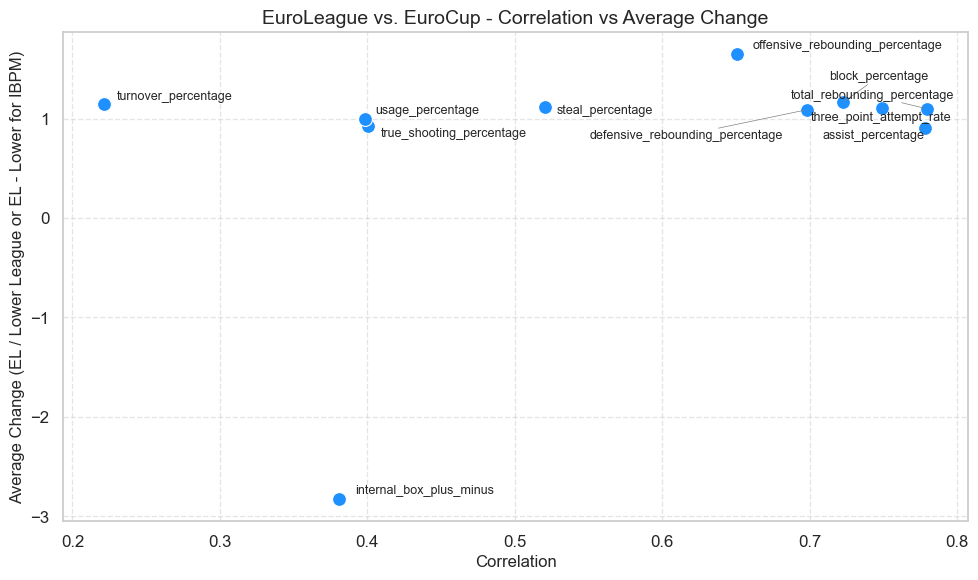

In [42]:
plot_league_correlation(ec_summary, 'EuroLeague vs. EuroCup')

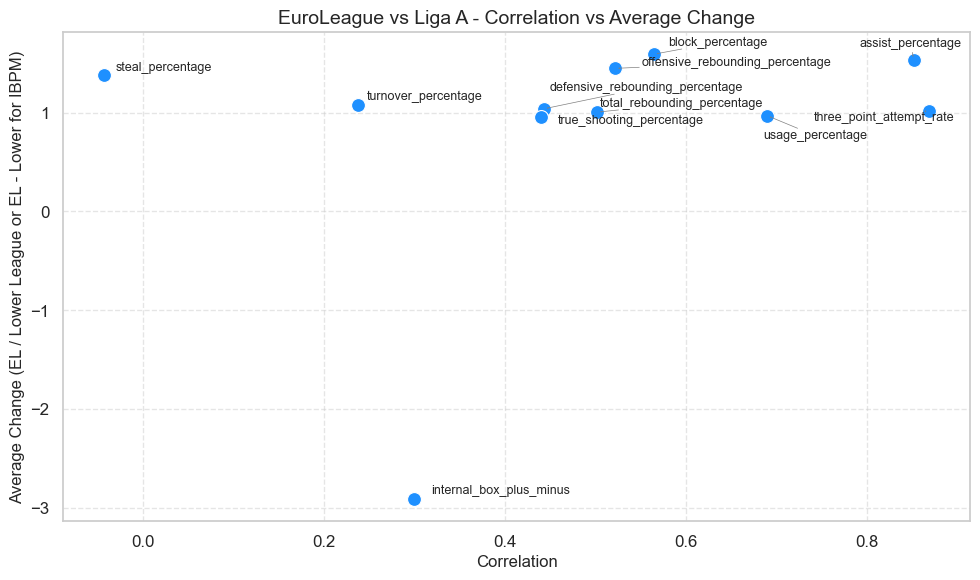

In [43]:
plot_league_correlation(la_summary, 'EuroLeague vs Liga A')

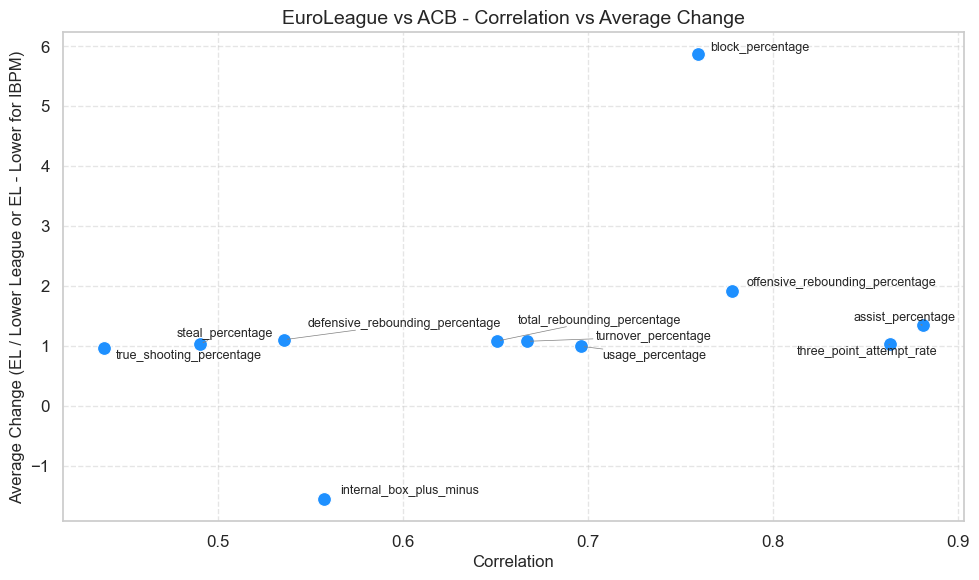

In [44]:
plot_league_correlation(acb_summary, 'EuroLeague vs ACB')

### Identifying Trends in Players That Make the Jump to the NBA from the 4 Leagues

In [85]:
agg_nba_df = (
    nba_df
    .groupby('full_name', as_index=False)
    .agg(
        earliest_nba_season=('season', 'min'),
        avg_nba_ibpm=('internal_box_plus_minus', 'mean')
    )
)

In [86]:
agg_nba_df.head()

,full_name,earliest_nba_season,avg_nba_ibpm
0,abass warren,2014,-2.604033
1,abdul flynn,2020,-1.091900
2,agbelese butterfield,2010,-2.119900
3,ager koenig,2015,-3.061500
4,ahearn barnies,2013,-4.216200


In [87]:
joined_df = international_df.merge(agg_nba_df, on='full_name', how='left')

In [88]:
joined_df.head()

,first_name,last_name,season,season_type,league,team,games,starts,minutes,points,two_points_made,two_points_attempted,three_points_made,three_points_attempted,free_throws_made,free_throws_attempted,blocked_shot_attempts,offensive_rebounds,defensive_rebounds,assists,screen_assists,turnovers,steals,deflections,loose_balls_recovered,blocked_shots,personal_fouls,personal_fouls_drawn,offensive_fouls,charges_drawn,technical_fouls,flagrant_fouls,ejections,points_off_turnovers,points_in_paint,second_chance_points,fast_break_points,possessions,estimated_possessions,team_possessions,usage_percentage,true_shooting_percentage,three_point_attempt_rate,free_throw_rate,offensive_rebounding_percentage,defensive_rebounding_percentage,total_rebounding_percentage,assist_percentage,steal_percentage,block_percentage,turnover_percentage,internal_box_plus_minus,full_name,birth_date,age,earliest_nba_season,avg_nba_ibpm
0,theo,greene,2021,Full Season,EuroLeague,Redhawks,25,18,527.61,195,40,78,30,74,25,31,5,8,59,58,0,26,13,0,0,0,40,39,0,0,0,0,0,0,0,0,0,919.7698,919.7698,1778.1345,18.2974,0.5886,0.4868,0.2039,3.2474,13.4519,9.7267,19.0212,1.8221,0.0000,13.5671,0.7786,theo greene,1995-12-26,25.51,NaN,NaN
1,theo,greene,2021,Full Season,Spain - ACB,Redhawks,17,10,356.70,135,26,56,20,43,23,29,2,11,40,37,0,14,7,0,0,1,20,26,0,0,0,0,0,0,0,0,0,652.1629,652.1629,1461.3459,16.9730,0.6040,0.4343,0.2929,3.7781,13.5418,9.9234,14.7139,0.8723,0.8292,11.1323,2.7367,theo greene,1995-12-26,25.51,NaN,NaN
2,miles,brussino,2021,Full Season,EuroCup,Orange,12,2,204.70,82,14,25,11,27,21,22,2,3,27,9,0,10,6,0,0,5,22,20,0,0,0,0,0,0,0,0,0,386.7079,386.7079,1057.9286,16.5449,0.6647,0.5192,0.4231,3.0377,14.5608,10.4102,5.2539,1.5268,3.0675,13.9509,3.2200,miles brussino,1993-02-01,28.41,NaN,NaN
3,miles,brussino,2021,Full Season,Italy - Liga A,Orange,16,3,266.00,83,24,47,5,25,20,24,2,7,30,8,0,7,9,0,0,3,24,20,0,0,0,0,0,0,0,0,0,500.4995,500.4995,1354.7356,15.5460,0.5027,0.3472,0.3333,3.7641,14.6187,8.9342,4.4051,1.9879,1.4668,7.8160,-1.5619,miles brussino,1993-02-01,28.41,NaN,NaN
4,kadoshnikov,christmas,2012,Full Season,EuroLeague,Redbirds,6,1,70.48,15,3,8,2,15,3,4,1,3,4,3,0,4,2,0,0,2,6,6,0,0,0,0,0,0,0,0,0,129.6115,129.6115,1186.1618,19.0997,0.3029,0.6522,0.1739,4.2915,6.9312,6.6163,5.7849,1.8662,2.4437,13.9082,-5.7589,kadoshnikov christmas,1993-08-10,18.89,2017.0,-2.0864


In [89]:
joined_el_df = joined_df[joined_df['league'] == 'EuroLeague']
joined_ec_df = joined_df[joined_df['league'] == 'EuroCup']
joined_acb_df = joined_df[joined_df['league'] == 'Spain - ACB']
joined_la_df = joined_df[joined_df['league'] == 'Italy - Liga A']

In [91]:
def get_latest_pre_nba_row(group):
    """
    For each player group:
    - If earliest_nba_season exists, return the row with the latest season < earliest_nba_season
      (if any). If none exist, return NaN.
    - If earliest_nba_season is missing (NaN), return the row with the latest season overall.
    """
    earliest_nba = group['earliest_nba_season'].iloc[0]  # or 'earliest_nba_season' if that's your column name

    if pd.notna(earliest_nba):
        # Filter for seasons before earliest NBA season
        before_nba = group[group['season'] < earliest_nba]
        if not before_nba.empty:
            return before_nba.loc[[before_nba['season'].idxmax()]]
        else:
            return pd.DataFrame(columns=group.columns)  # no valid pre-NBA season
    else:
        # No NBA career → return latest season
        return group.loc[[group['season'].idxmax()]]


def aggregate_latest_pre_nba(df):
    """
    Groups the given league DataFrame by 'full_name' and applies the logic above.
    """
    result = (
        df.groupby('full_name', group_keys=False)
          .apply(get_latest_pre_nba_row)
          .reset_index(drop=True)
    )

    # Rename the column safely if it exists
    if 'season' in result.columns:
        result = result.rename(columns={'season': 'latest_season_before_nba'})
    
    return result

In [92]:
# Apply to each league
agg_el_df = aggregate_latest_pre_nba(joined_el_df)
agg_ec_df = aggregate_latest_pre_nba(joined_ec_df)
agg_acb_df = aggregate_latest_pre_nba(joined_acb_df)
agg_la_df = aggregate_latest_pre_nba(joined_la_df)

In [95]:
def add_jump_column(df):
    """
    Adds a 'jump' column:
    - True if latest_season_before_nba < earliest_nba_season
    - False otherwise (including if earliest_nba_season is NaN)
    """
    df['jump'] = (
        (df['latest_season_before_nba'] < df['earliest_nba_season'])
        & df['earliest_nba_season'].notna()
    )
    return df

In [96]:
# Apply to all four DataFrames
agg_el_df = add_jump_column(agg_el_df)
agg_ec_df = add_jump_column(agg_ec_df)
agg_acb_df = add_jump_column(agg_acb_df)
agg_la_df = add_jump_column(agg_la_df)

In [98]:
agg_el_df[agg_el_df['full_name'] == 'kadoshnikov christmas']

,first_name,last_name,latest_season_before_nba,season_type,league,team,games,starts,minutes,points,two_points_made,two_points_attempted,three_points_made,three_points_attempted,free_throws_made,free_throws_attempted,blocked_shot_attempts,offensive_rebounds,defensive_rebounds,assists,screen_assists,turnovers,steals,deflections,loose_balls_recovered,blocked_shots,personal_fouls,personal_fouls_drawn,offensive_fouls,charges_drawn,technical_fouls,flagrant_fouls,ejections,points_off_turnovers,points_in_paint,second_chance_points,fast_break_points,possessions,estimated_possessions,team_possessions,usage_percentage,true_shooting_percentage,three_point_attempt_rate,free_throw_rate,offensive_rebounding_percentage,defensive_rebounding_percentage,total_rebounding_percentage,assist_percentage,steal_percentage,block_percentage,turnover_percentage,internal_box_plus_minus,full_name,birth_date,age,earliest_nba_season,avg_nba_ibpm,jump
173,kadoshnikov,christmas,2016,Full Season,EuroLeague,Lions,25,2,480.53,232,36,66,40,96,40,48,5,15,39,21,0,12,14,0,0,3,40,46,0,0,0,0,0,0,0,0,0,823.7213,823.7213,2014.1771,20.7245,0.6335,0.5926,0.2963,3.5384,9.4447,7.7603,10.8531,1.7896,1.1664,6.1501,4.6497,kadoshnikov christmas,1993-08-10,22.89,2017.0,-2.0864,True


In [103]:
def summarize_jump_info(df, league_name):
    print(f"--- {league_name} ---")
    print("Jump value counts:")
    print(df['jump'].value_counts(dropna=False))
    
    true_pct = (df['jump'].sum() / len(df)) * 100
    print(f"\nPercentage of Players that Made the NBA: {true_pct:.2f}%")
    
    print("\nRows where earliest_nba_season is empty:")
    print(df['earliest_nba_season'].isna().sum())
    print("\n")

In [104]:
# Apply to all four
summarize_jump_info(agg_el_df, "EuroLeague")
summarize_jump_info(agg_ec_df, "EuroCup")
summarize_jump_info(agg_acb_df, "Spain - ACB")
summarize_jump_info(agg_la_df, "Italy - Liga A")

--- EuroLeague ---
Jump value counts:
False    274
True      82
Name: jump, dtype: int64

Percentage of Players that Made the NBA: 23.03%

Rows where earliest_nba_season is empty:
274


--- EuroCup ---
Jump value counts:
False    429
True      65
Name: jump, dtype: int64

Percentage of Players that Made the NBA: 13.16%

Rows where earliest_nba_season is empty:
429


--- Spain - ACB ---
Jump value counts:
False    339
True      49
Name: jump, dtype: int64

Percentage of Players that Made the NBA: 12.63%

Rows where earliest_nba_season is empty:
339


--- Italy - Liga A ---
Jump value counts:
False    273
True      19
Name: jump, dtype: int64

Percentage of Players that Made the NBA: 6.51%

Rows where earliest_nba_season is empty:
273




**Takeaways:**
- Just from this output, I can verify that I am only looking at players that played internationally first. There are no players here that played in the NBA first then went international.
- Additionally, by looking at the percentage of players that made the NBA I can immediately see the EuroLeague has the highest placement rate of players making it to the NBA.

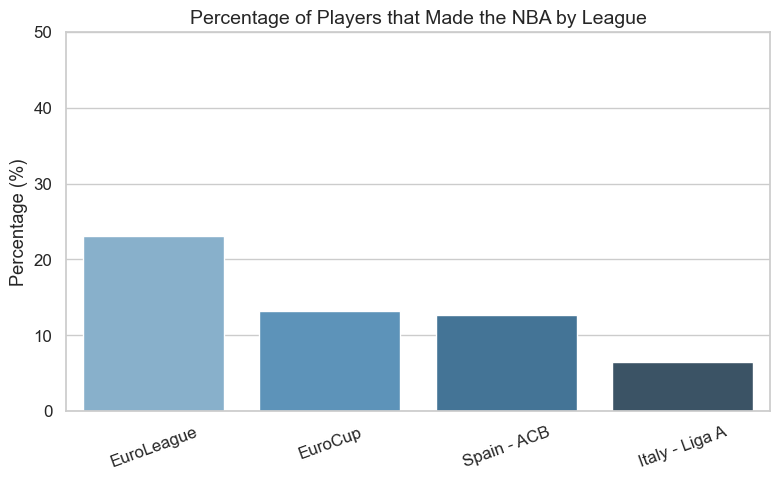

In [106]:
# Calculate the percentage for each league
leagues = {
    'EuroLeague': agg_el_df,
    'EuroCup': agg_ec_df,
    'Spain - ACB': agg_acb_df,
    'Italy - Liga A': agg_la_df
}

data = []
for league_name, df in leagues.items():
    pct = (df['jump'].sum() / len(df)) * 100
    data.append({'League': league_name, 'Percentage of Players that Made the NBA': pct})

plot_df = pd.DataFrame(data)

# Plot
plt.figure(figsize=(8, 5))
sns.barplot(
    data=plot_df,
    x='League',
    y='Percentage of Players that Made the NBA',
    palette='Blues_d'
)

plt.title('Percentage of Players that Made the NBA by League', fontsize=14)
plt.ylabel('Percentage (%)')
plt.xlabel('')
plt.ylim(0, 50)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [111]:
leagues = {
    'EuroLeague': agg_el_df,
    'EuroCup': agg_ec_df,
    'Spain - ACB': agg_acb_df,
    'Italy - Liga A': agg_la_df
}

for league_name, df in leagues.items():
    # Count players whose latest international season is 2021 and have not played in the NBA
    count = len(df[
        (df['latest_season_before_nba'] == 2021) &
        (df['earliest_nba_season'].isna())
    ])
    
    print(f"{count} players in {league_name} are still playing internationally in 2021 "
          f"that have not played in the NBA that we can analyze.")

218 players in EuroLeague are still playing internationally in 2021 that have not played in the NBA that we can analyze.
314 players in EuroCup are still playing internationally in 2021 that have not played in the NBA that we can analyze.
275 players in Spain - ACB are still playing internationally in 2021 that have not played in the NBA that we can analyze.
207 players in Italy - Liga A are still playing internationally in 2021 that have not played in the NBA that we can analyze.
